# EDA

In [1]:
# ================================ EDA =============================================
# 1. Import Required Libraries
# ================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set visualization style
sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)

In [2]:
# ================================
# 2. Load the Dataset
# ================================
df = pd.read_csv("Dataset (2).csv")

In [3]:
# ================================
# 3. Describe the Dataset
# ================================
print("Dataset Shape:", df.shape)
print("\nDataset Info:")
df.info()

print("\nFirst 5 rows:")
print(df.head())

print("\nStatistical Summary:")
print(df.describe())

Dataset Shape: (17379, 17)

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17379 entries, 0 to 17378
Data columns (total 17 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   instant     17379 non-null  int64 
 1   dteday      17379 non-null  object
 2   season      17379 non-null  object
 3   yr          17379 non-null  object
 4   mnth        17379 non-null  object
 5   hr          17379 non-null  int64 
 6   holiday     17379 non-null  object
 7   weekday     17379 non-null  int64 
 8   workingday  17379 non-null  object
 9   weathersit  17379 non-null  object
 10  temp        17379 non-null  object
 11  atemp       17379 non-null  object
 12  hum         17379 non-null  object
 13  windspeed   17379 non-null  object
 14  casual      17379 non-null  object
 15  registered  17379 non-null  object
 16  cnt         17379 non-null  int64 
dtypes: int64(4), object(13)
memory usage: 2.3+ MB

First 5 rows:
   instant      dteday 

In [4]:
# ================================
# 4. Data Cleaning
# ================================

# Check for duplicate records
duplicates = df.duplicated().sum()
print("\nDuplicate Records:", duplicates)

if duplicates > 0:
    df = df.drop_duplicates()


Duplicate Records: 0


In [5]:
# ================================
# 5. Missing Value Detection
# ================================
print("\nMissing Values in Each Column:")
print(df.isnull().sum())



Missing Values in Each Column:
instant       0
dteday        0
season        0
yr            0
mnth          0
hr            0
holiday       0
weekday       0
workingday    0
weathersit    0
temp          0
atemp         0
hum           0
windspeed     0
casual        0
registered    0
cnt           0
dtype: int64


In [6]:
# ================================
# 6. Handle Missing Values
# ================================

# Numerical columns
num_cols = df.select_dtypes(include=np.number).columns

# Categorical columns
cat_cols = df.select_dtypes(include="object").columns

# Impute numerical columns with median
for col in num_cols:
    df[col].fillna(df[col].median(), inplace=True)

# Impute categorical columns with mode
for col in cat_cols:
    df[col].fillna(df[col].mode()[0], inplace=True)

print("\nMissing Values After Imputation:")
print(df.isnull().sum())


Missing Values After Imputation:
instant       0
dteday        0
season        0
yr            0
mnth          0
hr            0
holiday       0
weekday       0
workingday    0
weathersit    0
temp          0
atemp         0
hum           0
windspeed     0
casual        0
registered    0
cnt           0
dtype: int64


C:\Users\Shri\AppData\Local\Temp\ipykernel_7224\3396482168.py:13: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].median(), inplace=True)
C:\Users\Shri\AppData\Local\Temp\ipykernel_7224\3396482168.py:13: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example

In [7]:
# ================================
# 7. Outlier Detection (IQR Method)
# ================================

def detect_outliers_iqr(data, column):
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    return data[(data[column] < lower) | (data[column] > upper)]

# Detect outliers in numerical columns
outlier_summary = {}

for col in num_cols:
    outliers = detect_outliers_iqr(df, col)
    outlier_summary[col] = outliers.shape[0]

print("\nOutlier Count Per Numerical Column:")
for key, value in outlier_summary.items():
    print(f"{key}: {value}")


Outlier Count Per Numerical Column:
instant: 0
hr: 0
weekday: 0
cnt: 505


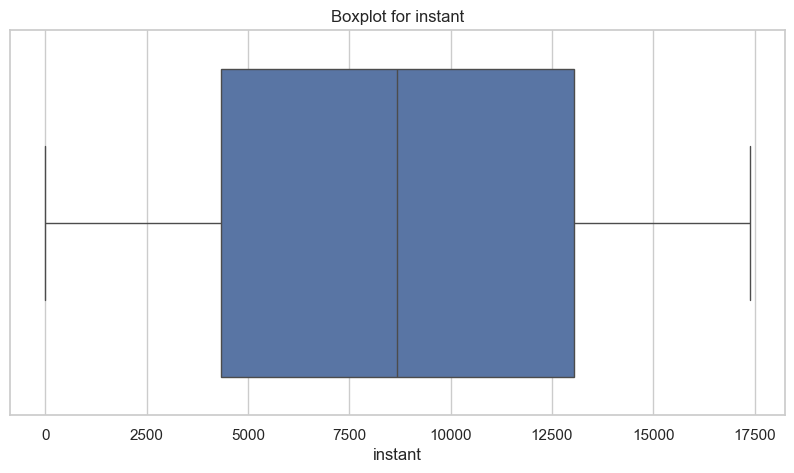

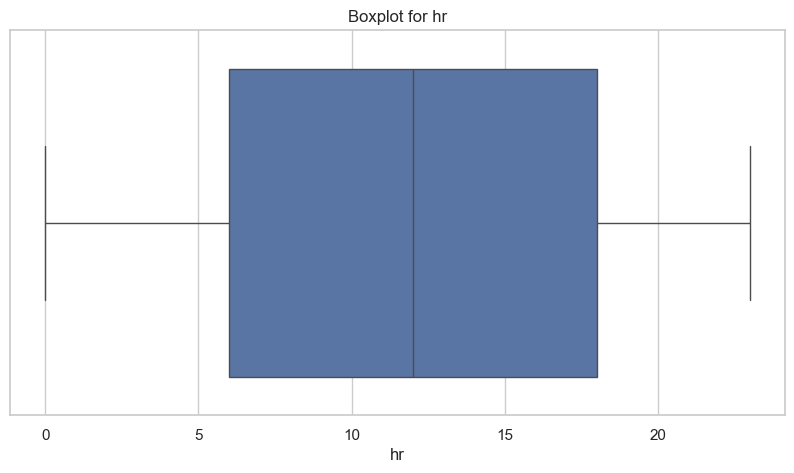

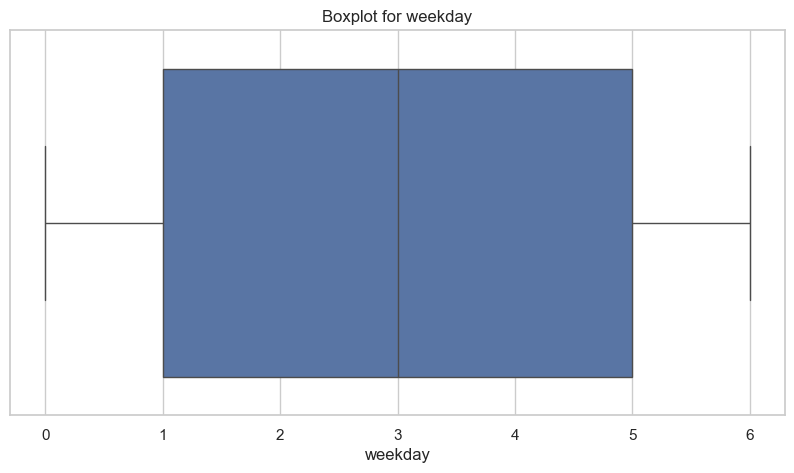

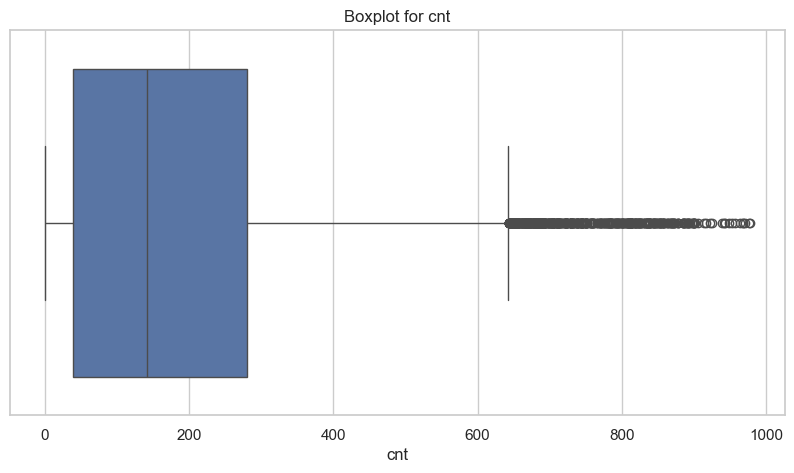

In [8]:
# ================================
# 8. Outlier Visualization
# ================================
for col in num_cols:
    sns.boxplot(x=df[col])
    plt.title(f"Boxplot for {col}")
    plt.show()


In [9]:
# ================================
# 9. Optional: Outlier Treatment (Capping)
# ================================
for col in num_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    df[col] = np.where(df[col] < lower, lower, df[col])
    df[col] = np.where(df[col] > upper, upper, df[col])

print("\nOutliers treated using IQR capping.")


Outliers treated using IQR capping.


In [10]:
# ================================
# 10. Final Cleaned Dataset
# ================================
print("\nFinal Dataset Shape:", df.shape)
print("\nFinal Dataset Info:")
df.info()



Final Dataset Shape: (17379, 17)

Final Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17379 entries, 0 to 17378
Data columns (total 17 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     17379 non-null  float64
 1   dteday      17379 non-null  object 
 2   season      17379 non-null  object 
 3   yr          17379 non-null  object 
 4   mnth        17379 non-null  object 
 5   hr          17379 non-null  float64
 6   holiday     17379 non-null  object 
 7   weekday     17379 non-null  float64
 8   workingday  17379 non-null  object 
 9   weathersit  17379 non-null  object 
 10  temp        17379 non-null  object 
 11  atemp       17379 non-null  object 
 12  hum         17379 non-null  object 
 13  windspeed   17379 non-null  object 
 14  casual      17379 non-null  object 
 15  registered  17379 non-null  object 
 16  cnt         17379 non-null  float64
dtypes: float64(4), object(13)
memory usage: 2.3+ MB


# Data Visualization

In [11]:
# ==================================== Data Visualization ===========================
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)

df = pd.read_csv("Dataset (2).csv")
df['dteday'] = pd.to_datetime(df['dteday'], dayfirst=True)

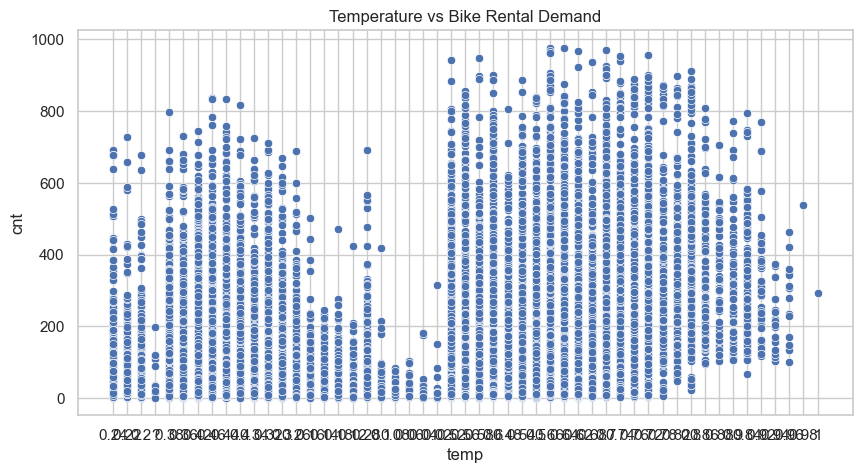

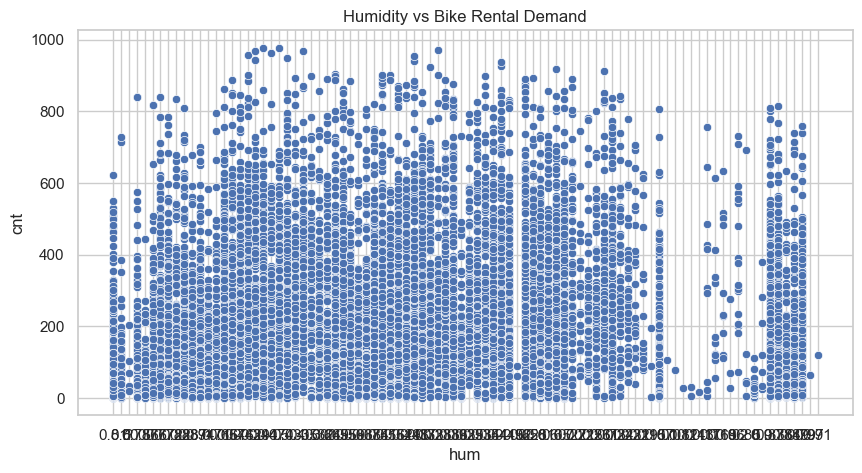

In [12]:
#=============================== Scatter Plot ================
sns.scatterplot(x='temp', y='cnt', data=df)
plt.title("Temperature vs Bike Rental Demand")
plt.show()

sns.scatterplot(x='hum', y='cnt', data=df)
plt.title("Humidity vs Bike Rental Demand")
plt.show()

In [13]:
# Convert date column if present
if 'datetime' in df.columns:
    df['datetime'] = pd.to_datetime(df['datetime'])
elif 'date' in df.columns:
    df['date'] = pd.to_datetime(df['date'])

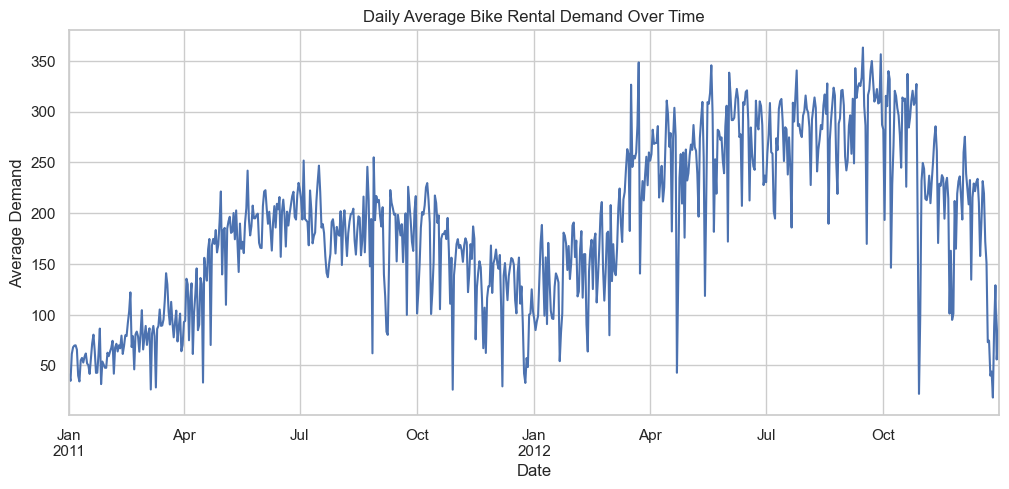

In [14]:
df['dteday'] = pd.to_datetime(df['dteday'], dayfirst=True)
# ================================
# 2. Line Plot (Time Series)
# ================================

# Time series trend
if 'dteday' in df.columns and 'cnt' in df.columns:
    df.set_index('dteday')['cnt'].resample('D').mean().plot(figsize=(12,5))
    plt.title("Daily Average Bike Rental Demand Over Time")
    plt.xlabel("Date")
    plt.ylabel("Average Demand")
    plt.show()

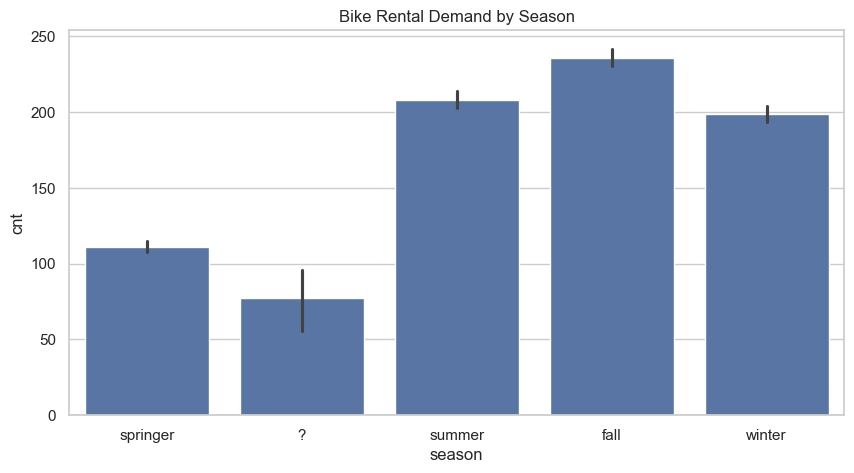

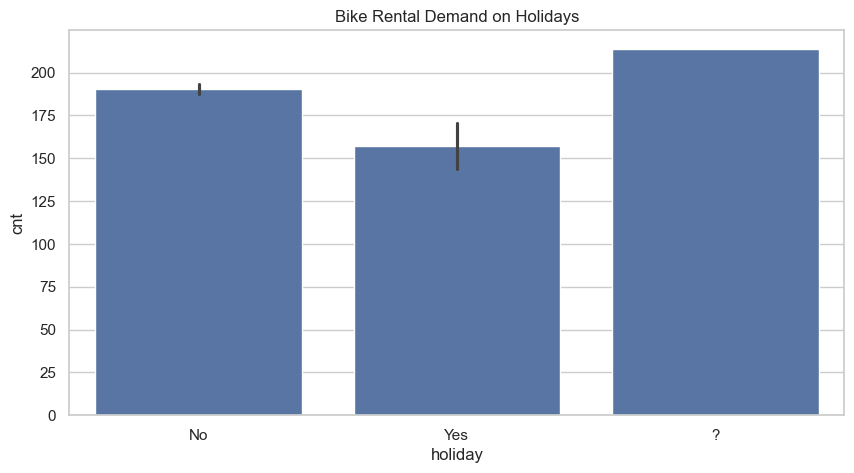

In [15]:
# =============================== Bar Plot =================
sns.barplot(x='season', y='cnt', data=df)
plt.title("Bike Rental Demand by Season")
plt.show()

sns.barplot(x='holiday', y='cnt', data=df)
plt.title("Bike Rental Demand on Holidays")
plt.show()


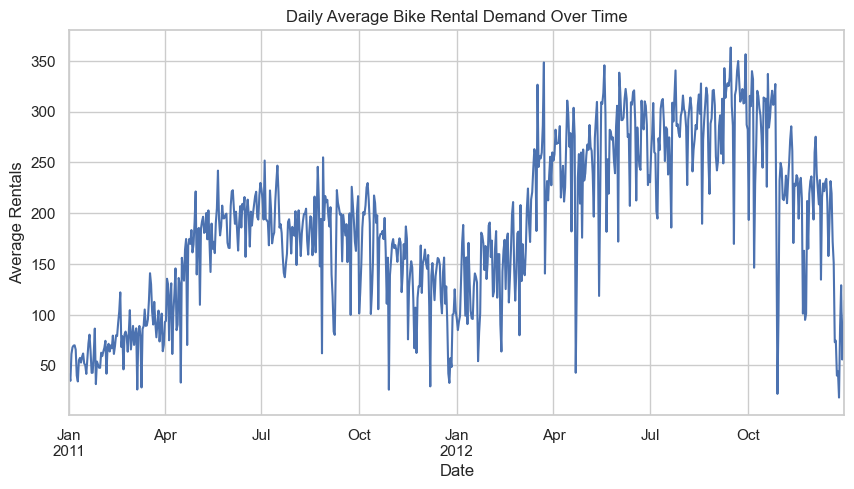

In [16]:
# ==================================== Time Series Analysis ===========================
daily_avg = df.groupby('dteday')['cnt'].mean()

daily_avg.plot()
plt.title("Daily Average Bike Rental Demand Over Time")
plt.xlabel("Date")
plt.ylabel("Average Rentals")
plt.show()


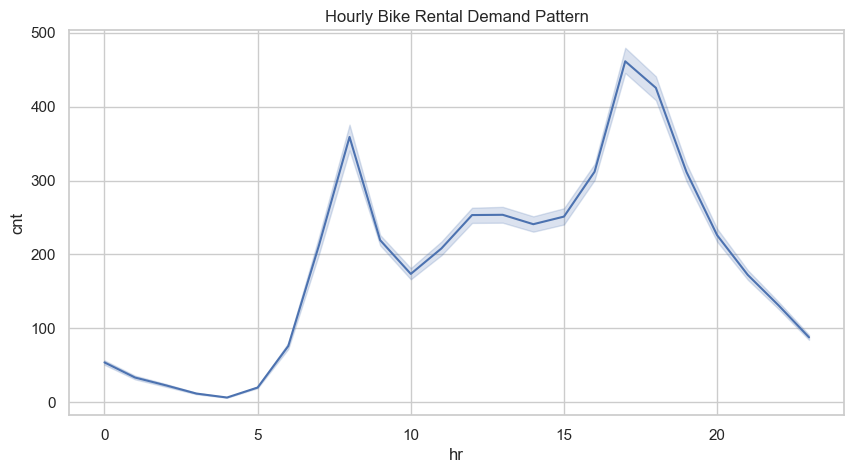

In [17]:
# ==================================== Hourly Seasonality ==========================
sns.lineplot(x='hr', y='cnt', data=df)
plt.title("Hourly Bike Rental Demand Pattern")
plt.show()


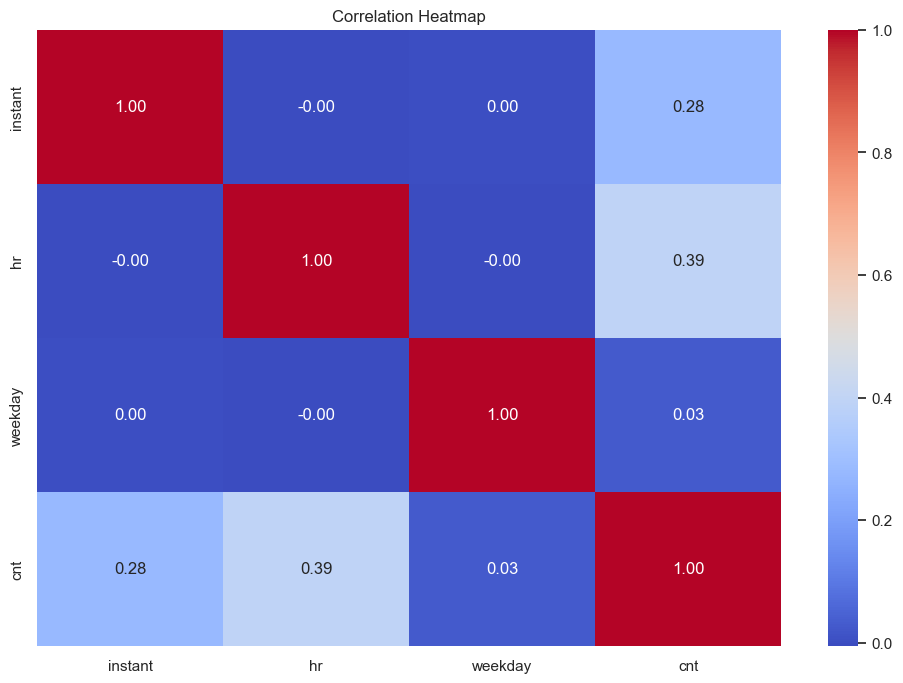

In [18]:
# ============================== Correlation Heatmap ==================================
num_df = df.select_dtypes(include=['int64', 'float64'])

plt.figure(figsize=(12, 8))
sns.heatmap(num_df.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()



# Feature Engineering

In [19]:
# =============================== Feature Engineering =================================
# Loading Dataset
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler

# Load dataset
df = pd.read_csv("Dataset (2).csv")

# Convert date column correctly
df['dteday'] = pd.to_datetime(df['dteday'], dayfirst=True)


In [20]:
# Generating New Features (Feature Creation)
# Extract useful date features
df['day'] = df['dteday'].dt.day
df['month'] = df['dteday'].dt.month
df['year'] = df['dteday'].dt.year
df['dayofweek'] = df['dteday'].dt.dayofweek
df['is_weekend'] = df['dayofweek'].apply(lambda x: 1 if x >= 5 else 0)


In [21]:
df[['casual', 'registered', 'cnt']].dtypes
cols = ['casual', 'registered', 'cnt']

for col in cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')
df[cols] = df[cols].fillna(0)


In [22]:
# Demand Ratio Feature
df['casual_ratio'] = df['casual'] / (df['cnt'] + 1)
df['registered_ratio'] = df['registered'] / (df['cnt'] + 1)

In [23]:
# Peak Hour Feature (Domain Knowledge)
df['is_peak_hour'] = df['hr'].apply(lambda x: 1 if x in [7,8,9,17,18,19] else 0)


In [24]:
# Handling Categorical Variables
# One-Hot Encoding
df = pd.get_dummies(df, columns=['season', 'weathersit'], drop_first=True)


In [25]:
(df == '?').sum()
df.replace('?', np.nan, inplace=True)
num_cols = [
    'temp', 'atemp', 'hum', 'windspeed',
    'casual', 'registered', 'cnt'
]

for col in num_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')
df[num_cols] = df[num_cols].fillna(df[num_cols].median())


In [26]:
# Feature Scaling / Normalization
scaler = StandardScaler()

num_cols = [
    'temp', 'atemp', 'hum', 'windspeed',
    'casual', 'registered'
]

df[num_cols] = scaler.fit_transform(df[num_cols])


In [27]:
# Final Feature Set Preparation
# Drop columns not needed for modeling
df_model = df.drop(columns=['dteday', 'instant'])

print("Final feature set shape:", df_model.shape)
df_model.head()


Final feature set shape: (17379, 29)


,yr,mnth,hr,holiday,weekday,workingday,temp,atemp,hum,windspeed,...,registered_ratio,is_peak_hour,season_fall,season_springer,season_summer,season_winter,weathersit_Clear,weathersit_Heavy Rain,weathersit_Light Snow,weathersit_Mist
0,2011,1,0,No,6,No work,-1.336047,-1.094064,0.947596,-1.554228,...,0.764706,0,False,True,False,False,True,False,False,False
1,2011,1,1,No,6,No work,-1.439966,-1.182542,0.895755,-1.554228,...,0.780488,0,False,True,False,False,True,False,False,False
2,2011,1,2,No,6,No work,-1.439966,-1.182542,0.014470,-1.554228,...,0.818182,0,False,True,False,False,True,False,False,False
3,2011,1,3,No,6,No work,-1.336047,-1.094064,0.636554,-1.554228,...,0.714286,0,False,True,False,False,True,False,False,False
4,2011,1,4,No,6,No work,-1.336047,-1.094064,0.636554,-1.554228,...,0.500000,0,False,True,False,False,True,False,False,False


# Model Building

In [28]:
# Importing Libraries
import pandas as pd 
import numpy as np 
from sklearn.model_selection import train_test_split, GridSearchCV 
from sklearn.tree import DecisionTreeRegressor 
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score 
from sklearn.compose import ColumnTransformer 
from sklearn.preprocessing import OneHotEncoder, StandardScaler 
from sklearn.pipeline import Pipeline

In [29]:
# Load the dataset
df = pd.read_csv("Dataset (2).csv")

In [30]:
# Display first rows
print(df.head())

   instant      dteday    season    yr mnth  hr holiday  weekday workingday  \
0        1  01-01-2011  springer  2011    1   0      No        6    No work   
1        2  01-01-2011  springer  2011    1   1      No        6    No work   
2        3  01-01-2011  springer  2011    1   2      No        6    No work   
3        4  01-01-2011  springer  2011    1   3      No        6    No work   
4        5  01-01-2011  springer  2011    1   4      No        6    No work   

  weathersit  temp   atemp   hum windspeed casual registered  cnt  
0      Clear  0.24  0.2879  0.81         0      3         13   16  
1      Clear  0.22  0.2727   0.8         0      8         32   40  
2      Clear  0.22  0.2727     ?         0      5         27   32  
3      Clear  0.24  0.2879  0.75         0      3         10   13  
4      Clear  0.24  0.2879  0.75         0      0          1    1  


In [31]:
# Check for missing values
print(df.isnull().sum())

instant       0
dteday        0
season        0
yr            0
mnth          0
hr            0
holiday       0
weekday       0
workingday    0
weathersit    0
temp          0
atemp         0
hum           0
windspeed     0
casual        0
registered    0
cnt           0
dtype: int64


In [32]:
# Feature & Target Selection
# Drop leakage and non-predictive columns
X = df.drop(
    columns=['cnt', 'instant', 'dteday', 'casual', 'registered', 'hr'],
    errors='ignore'
)
y = df['cnt']                  # Target

In [33]:
# ----------------------------- 
# 2. Identify categorical & numeric columns 
# ----------------------------- 
categorical_cols = X.select_dtypes(include=["object"]).columns 
numeric_cols = X.select_dtypes(include=["int64", "float64"]).columns

In [34]:
# ----------------------------- 
# 3. Preprocessing 
# ----------------------------- 
preprocessor = ColumnTransformer( 
    transformers=[ 
        ("num", StandardScaler(), numeric_cols), 
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols), 
    ] 
)

In [35]:
# ----------------------------- 
# 2. Train-test split 
# ----------------------------- 
X_train, X_test, y_train, y_test = train_test_split( 
    X, y, test_size=0.2, random_state=42 
)

In [36]:
# Train & Evaluate Models
models = { "Decision Tree": DecisionTreeRegressor(random_state=42), 
           "Random Forest": RandomForestRegressor(random_state=42), 
           "Gradient Boosting": GradientBoostingRegressor(random_state=42), 
           "XG Boost": XGBRegressor(random_state=42)
}

results = {}

for name, model in models.items(): 
    pipeline = Pipeline(steps=[("preprocessor", preprocessor), 
                               ("model", model)]) 
    pipeline.fit(X_train, y_train) 
    y_pred = pipeline.predict(X_test) 
    
    rmse = np.sqrt(mean_squared_error(y_test, y_pred)) 
    mae = mean_absolute_error(y_test, y_pred) 
    r2 = r2_score(y_test, y_pred) 
    
    results[name] = {"RMSE": rmse, "MAE": mae, "R²": r2} 
# Print results 
print("Model Performance:") 
for model_name, metrics in results.items(): 
    print(f"{model_name}: RMSE={metrics['RMSE']:.2f}, MAE={metrics['MAE']:.2f}, R²={metrics['R²']:.2f}")

Model Performance:
Decision Tree: RMSE=182.68, MAE=124.18, R²=-0.05
Random Forest: RMSE=138.55, MAE=98.22, R²=0.39
Gradient Boosting: RMSE=149.73, MAE=113.96, R²=0.29
XG Boost: RMSE=138.54, MAE=102.30, R²=0.39


# Hyperparameter Tuning 

In [37]:
# ----------------------------- 
# 4. Hyperparameter grids 
# ----------------------------- 
param_grid_dt = { 
    "model__max_depth": [None, 5, 10, 20], 
    "model__min_samples_split": [2, 5, 10], 
} 
param_grid_rf = { 
    "model__n_estimators": [100, 200], 
    "model__max_depth": [None, 10, 20], 
    "model__min_samples_split": [2, 5], 
} 
param_grid_gb = { 
    "model__n_estimators": [100, 200], 
    "model__learning_rate": [0.05, 0.1, 0.2], 
    "model__max_depth": [3, 5, 10], 
}
param_grid_xgb = {
    'model__n_estimators': [100, 200],
    'model__learning_rate': [0.05, 0.1, 0.2],
    'model__max_depth': [3, 5, 7]
}

In [38]:
# ----------------------------- 
# 5. Run GridSearchCV 
# ----------------------------- 
def tune_model(model, param_grid, name): 
    pipeline = Pipeline(steps=[("preprocessor", preprocessor), ("model", model)]) 
    
    grid_search = GridSearchCV( 
        pipeline, 
        param_grid, 
        cv=3, 
        scoring="neg_mean_squared_error", 
        n_jobs=-1 
) 
    
    grid_search.fit(X_train, y_train) 
    best_model = grid_search.best_estimator_

    y_pred = best_model.predict(X_test) 
    rmse = np.sqrt(mean_squared_error(y_test, y_pred)) 
    mae = mean_absolute_error(y_test, y_pred) 
    r2 = r2_score(y_test, y_pred) 
    
    print(f"\n{name} Best Params: {grid_search.best_params_}") 
    print(f"{name} Performance: RMSE={rmse:.2f}, MAE={mae:.2f}, R²={r2:.2f}") 
    return best_model

In [39]:
# Decision Tree 
best_dt = tune_model(DecisionTreeRegressor(random_state=42), param_grid_dt, "Decision Tree") 
# Random Forest 
best_rf = tune_model(RandomForestRegressor(random_state=42), param_grid_rf, "Random Forest") 
# Gradient Boosting 
best_gb = tune_model(GradientBoostingRegressor(random_state=42), param_grid_gb, "Gradient Boosting")
# XGBoost
best_xgb = tune_model(XGBRegressor(random_state=42), param_grid_xgb, "XG Boost")


Decision Tree Best Params: {'model__max_depth': 10, 'model__min_samples_split': 10}
Decision Tree Performance: RMSE=155.72, MAE=118.56, R²=0.23

Random Forest Best Params: {'model__max_depth': None, 'model__min_samples_split': 5, 'model__n_estimators': 200}
Random Forest Performance: RMSE=137.20, MAE=98.09, R²=0.41

Gradient Boosting Best Params: {'model__learning_rate': 0.05, 'model__max_depth': 10, 'model__n_estimators': 200}
Gradient Boosting Performance: RMSE=139.15, MAE=102.34, R²=0.39

XG Boost Best Params: {'model__learning_rate': 0.2, 'model__max_depth': 5, 'model__n_estimators': 200}
XG Boost Performance: RMSE=138.24, MAE=102.30, R²=0.40


# Model Evaluation

In [40]:
import pandas as pd
import numpy as np
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# -----------------------------
# Assume you already have trained models:
# best_dt, best_rf, best_gb (from hyperparameter tuning step)
# -----------------------------

# Collect models in a dictionary
models = {
    "Decision Tree": best_dt,
    "Random Forest": best_rf,
    "Gradient Boosting": best_gb,
    "XG Boost": best_xgb,
}

# -----------------------------
# Function to evaluate models
# -----------------------------
def evaluate_model(name, model, X_test, y_test):
    y_pred = model.predict(X_test)
    
    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, y_pred)
    
    return {"MAE": mae, "MSE": mse, "RMSE": rmse, "R²": r2}

# -----------------------------
# Evaluate all models
# -----------------------------
results = {}
for name, model in models.items():
    results[name] = evaluate_model(name, model, X_test, y_test)

# -----------------------------
# Convert results to DataFrame for easy comparison
# -----------------------------
results_df = pd.DataFrame(results).T
print("\nModel Evaluation Results:")
print(results_df)

# -----------------------------
# Identify best model (lowest RMSE or highest R²)
# -----------------------------
best_model_name = results_df['RMSE'].idxmin()
print(f"\nBest model based on RMSE: {best_model_name}")



Model Evaluation Results:
                          MAE           MSE        RMSE        R²
Decision Tree      118.558403  24249.995123  155.724099  0.234180
Random Forest       98.087470  18822.868586  137.196460  0.405570
Gradient Boosting  102.337769  19362.721148  139.149995  0.388521
XG Boost           102.295311  19111.662109  138.244935  0.396450

Best model based on RMSE: Random Forest


In [42]:
import pickle
# Save model
with open("model.pkl", "wb") as f:
    pickle.dump(pipeline, f)

print("✅ model.pkl created successfully")


✅ model.pkl created successfully
